In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.model_selection import train_test_split
import albumentations as A
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn


In [2]:
# Collect paths of all MRI and mask images
all_images = glob.glob(
    r"D:\AI Medical Imaging\Project\LGG MRI Segmentation Dataset\kaggle_3m\*\*.tif")

In [3]:
# Separate MRI images and tumor masks
image_paths = []
mask_paths = []

for path in all_images:
    if 'mask' in path:
        mask_paths.append(path)
    else:
        image_paths.append(path)

In [4]:
# Create image-mask pairs
pairs = []
for image_path in image_paths:
    mask_path = image_path.replace('.tif', '_mask.tif')
    if mask_path in mask_paths:
        pairs.append((image_path, mask_path))

In [5]:
# Initialize counters for tumor and non-tumor images
tumor_count = 0
no_tumor_count = 0
# Count images with and without tumor
for image_path, mask_path in pairs:
    # Read mask as grayscale image
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    # Check if the mask contains tumor pixels
    if np.count_nonzero(mask) > 0:
        tumor_count += 1
    else:
        no_tumor_count += 1

# Print the number of images with and without tumor
print("Images with tumor:", tumor_count)
print("Images without tumor:", no_tumor_count)

Images with tumor: 1373
Images without tumor: 2556


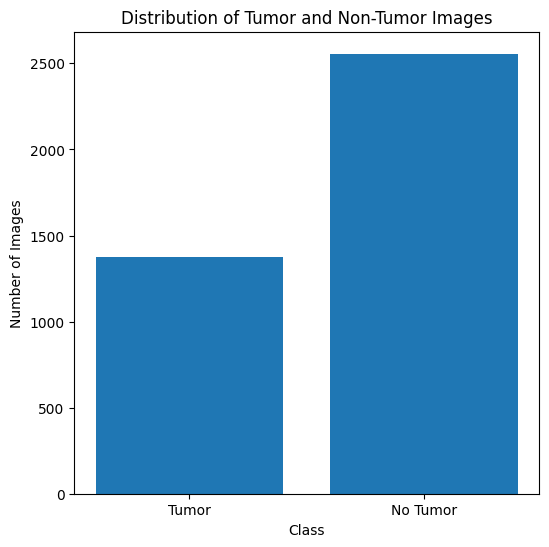

In [6]:
# Visualize the distribution of tumor and non-tumor images
labels = ['Tumor', 'No Tumor']
counts = [tumor_count, no_tumor_count]

plt.figure(figsize=(6, 6))
plt.bar(labels, counts)

plt.title('Distribution of Tumor and Non-Tumor Images')
plt.xlabel('Class')
plt.ylabel('Number of Images')

plt.show()

In [7]:
# Check if all MRI images and tumor masks have the same size
image_shapes = set()
mask_shapes = set()

for image_path, mask_path in pairs:

    image = cv2.imread(image_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    image_shapes.add(image.shape)
    mask_shapes.add(mask.shape)

print("Image shapes:", image_shapes)
print("Mask shapes:", mask_shapes)

Image shapes: {(256, 256, 3)}
Mask shapes: {(256, 256)}


In [9]:
# Data augmentation for training images
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=15,
        p=0.5
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.1,
        contrast_limit=0.1,
        p=0.3
    ),

    A.GaussNoise(
        std_range=(0.02, 0.05),
        p=0.2
    )

])

In [10]:
class BrainTumorDataset(Dataset):

    def __init__(self, pairs, transform=None):

        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        image_path, mask_path = self.pairs[idx]
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        # image = image / 255.0
        # mask = mask / 255.0
        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0
        # Apply augmentation
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)
        image = image.permute(2, 0, 1)
        mask = mask.unsqueeze(0)

        return image, mask

In [11]:
# Split dataset into training and validation sets
train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=42
)

print("Total samples:", len(pairs))
print("Training samples:", len(train_pairs))
print("Validation samples:", len(val_pairs))

Total samples: 3929
Training samples: 3143
Validation samples: 786


In [12]:
# Create training and validation datasets
train_dataset = BrainTumorDataset(
    train_pairs,
    transform=train_transform
)
val_dataset = BrainTumorDataset(
    val_pairs,
    transform=None
)
print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Train dataset size: 3143
Validation dataset size: 786


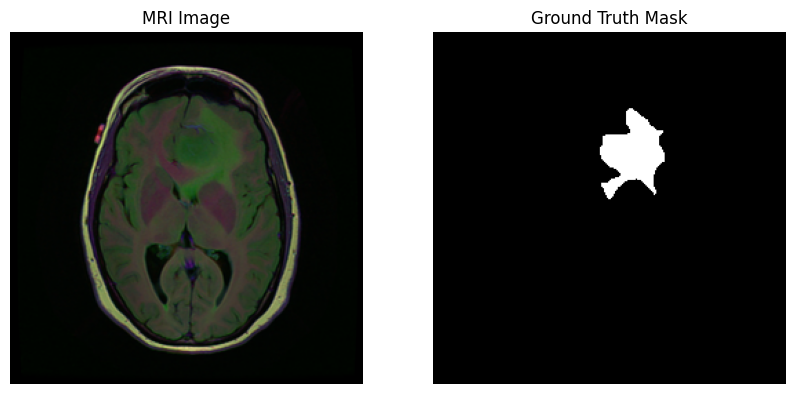

In [31]:
# Visualize a random MRI image and its mask
idx = np.random.randint(len(train_dataset))

image, mask = train_dataset[idx]

image = image.permute(1, 2, 0).numpy()
mask = mask.squeeze().numpy()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

In [13]:
# Create data loaders for training and validation datasets
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    pin_memory=True
)

In [14]:
# Create a double convolution block used in U-Net
class DoubleConv(nn.Module):
    # Initialize convolution layers
    def __init__(self, in_channels, out_channels):

        super().__init__()
        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    # Forward pass through the block
    def forward(self, x):

        return self.conv(x)

In [15]:
# Create an encoder block for U-Net
class EncoderBlock(nn.Module):
    # Initialize encoder layers
    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    # Forward pass through encoder block
    def forward(self, x):

        skip = self.conv(x)
        x = self.pool(skip)

        return skip, x

In [16]:
# Create a decoder block for U-Net
class DecoderBlock(nn.Module):
    # Initialize decoder layers
    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            out_channels * 2,
            out_channels
        )

    # Forward pass through decoder block
    def forward(self, x, skip):

        x = self.up(x)

        x = torch.cat([skip, x], dim=1)

        x = self.conv(x)

        return x

In [17]:
# Create the complete U-Net architecture
class UNet(nn.Module):

    # Initialize U-Net layers
    def __init__(self):

        super().__init__()

        # Encoder
        self.encoder1 = EncoderBlock(3, 64)
        self.encoder2 = EncoderBlock(64, 128)
        self.encoder3 = EncoderBlock(128, 256)
        self.encoder4 = EncoderBlock(256, 512)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            DoubleConv(512, 1024),
            nn.Dropout2d(p=0.3)
        )

        # Decoder
        self.decoder1 = DecoderBlock(1024, 512)
        self.decoder2 = DecoderBlock(512, 256)
        self.decoder3 = DecoderBlock(256, 128)
        self.decoder4 = DecoderBlock(128, 64)

        # Final output layer
        self.final_conv = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        skip1, x = self.encoder1(x)
        skip2, x = self.encoder2(x)
        skip3, x = self.encoder3(x)
        skip4, x = self.encoder4(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder
        x = self.decoder1(x, skip4)
        x = self.decoder2(x, skip3)
        x = self.decoder3(x, skip2)
        x = self.decoder4(x, skip1)

        # Final output layer
        x = self.final_conv(x)

        return x

In [18]:
# Create the U-Net model and move it to the available device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
print(device)

cuda


In [19]:
# Define Dice Loss
class DiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, outputs, targets):

        outputs = torch.sigmoid(outputs)

        intersection = (outputs * targets).sum()

        dice = (
            2 * intersection + 1e-8
        ) / (
            outputs.sum() + targets.sum() + 1e-8
        )

        return 1 - dice

# Define loss functions
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

Best model saved.
Epoch [1/30] | Train Loss: 0.4505 | Val Loss: 0.3184 | Dice: 0.4396 | Best Dice: 0.4396
Best model saved.
Epoch [2/30] | Train Loss: 0.3520 | Val Loss: 0.3102 | Dice: 0.4688 | Best Dice: 0.4688
Best model saved.
Epoch [3/30] | Train Loss: 0.3386 | Val Loss: 0.2963 | Dice: 0.4815 | Best Dice: 0.4815
Best model saved.
Epoch [4/30] | Train Loss: 0.3338 | Val Loss: 0.2820 | Dice: 0.5005 | Best Dice: 0.5005
Best model saved.
Epoch [5/30] | Train Loss: 0.3287 | Val Loss: 0.2768 | Dice: 0.5142 | Best Dice: 0.5142
Best model saved.
Epoch [6/30] | Train Loss: 0.3153 | Val Loss: 0.2661 | Dice: 0.5160 | Best Dice: 0.5160
Best model saved.
Epoch [7/30] | Train Loss: 0.3057 | Val Loss: 0.2460 | Dice: 0.5791 | Best Dice: 0.5791
Epoch [8/30] | Train Loss: 0.3087 | Val Loss: 0.2714 | Dice: 0.5324 | Best Dice: 0.5791
Epoch [9/30] | Train Loss: 0.3184 | Val Loss: 0.2489 | Dice: 0.5593 | Best Dice: 0.5791
Epoch [10/30] | Train Loss: 0.3187 | Val Loss: 0.2805 | Dice: 0.5122 | Best Dice: 

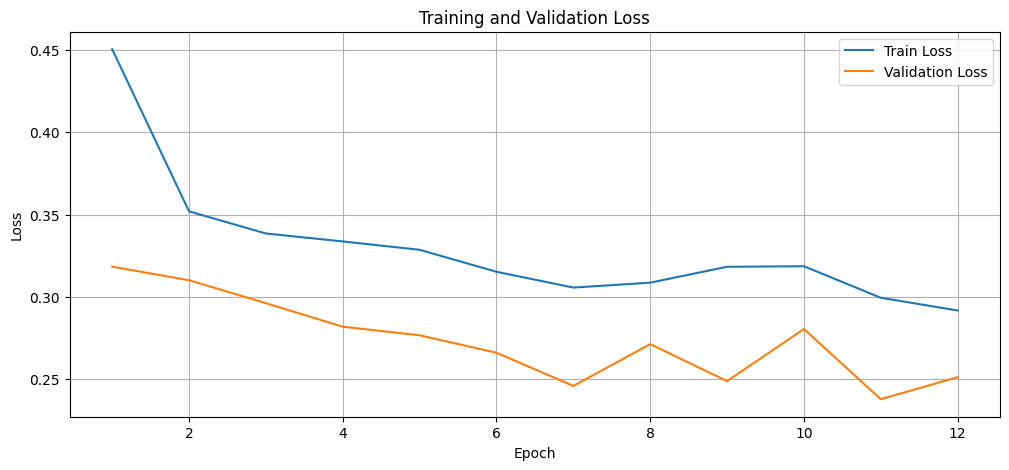

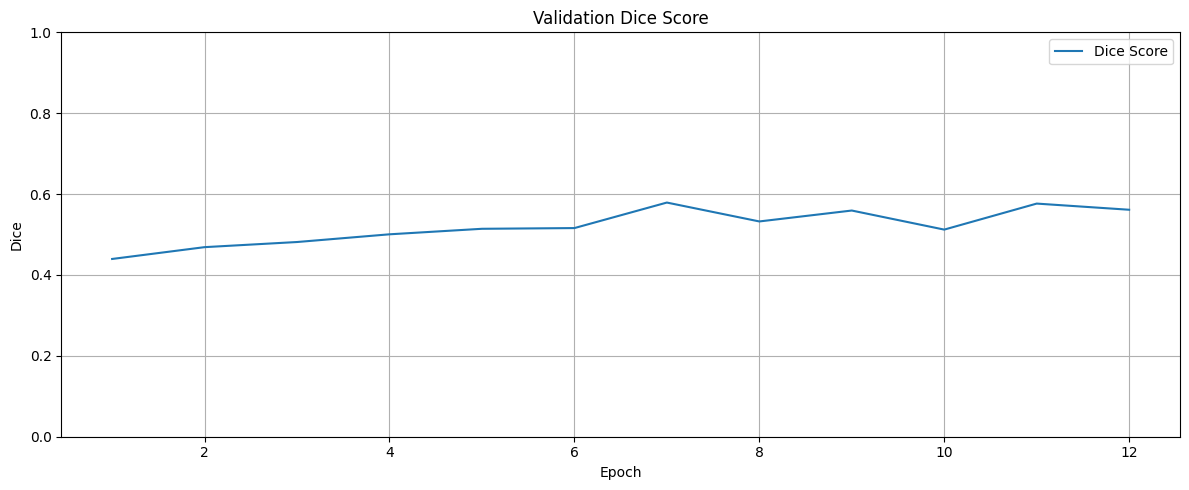

Training Finished
Best Dice Score: 0.5791


In [ ]:
#Training
def train(model, dataloader, optimizer):
    model.train()
    total_loss = 0
    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = (
            0.5 * bce_loss(outputs, masks)
            +
            0.5 * dice_loss(outputs, masks)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

# Validation
def validate(model, dataloader):
    model.eval()
    total_loss = 0
    total_dice = 0
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            loss = (
                0.5 * bce_loss(outputs, masks)
                +
                0.5 * dice_loss(outputs, masks)
            )
            total_loss += loss.item()
            outputs = torch.sigmoid(outputs)
            outputs = (outputs > 0.5).float()
            intersection = (outputs * masks).sum()
            dice = (
                2 * intersection + 1e-8
            ) / (
                outputs.sum() + masks.sum() + 1e-8
            )
            total_dice += dice.item()

    avg_loss = total_loss / len(dataloader)
    avg_dice = total_dice / len(dataloader)

    return avg_loss, avg_dice

train_losses = []
val_losses = []
dice_scores = []
num_epochs = 30
best_dice = 0.0
patience = 8
patience_counter = 0

for epoch in range(num_epochs):

    train_loss = train(
        model,
        train_loader,
        optimizer
    )

    val_loss, dice_score = validate(
        model,
        val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    dice_scores.append(dice_score)

    # Early Stopping + Save Best Model
    if dice_score > best_dice:
        best_dice = dice_score
        patience_counter = 0
        torch.save(
            model.state_dict(),
            "best_unet_model.pth"
        )
        print("Best model saved.")
    else:
        patience_counter += 1

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {dice_score:.4f} | "
        f"Best Dice: {best_dice:.4f}"
    ) 
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

    

# Plot training and validation losses
plt.figure(figsize=(12,5))
plt.plot(
    range(1, len(train_losses)+1),
    train_losses,
    label="Train Loss"
)
plt.plot(
    range(1, len(val_losses)+1),
    val_losses,
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

# Plot Dice Score
plt.figure(figsize=(12,5))
plt.plot(
    range(1, len(dice_scores)+1),
    dice_scores,
    label="Dice Score"
)

plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Validation Dice Score")
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print("Training Finished")
print(f"Best Dice Score: {best_dice:.4f}")

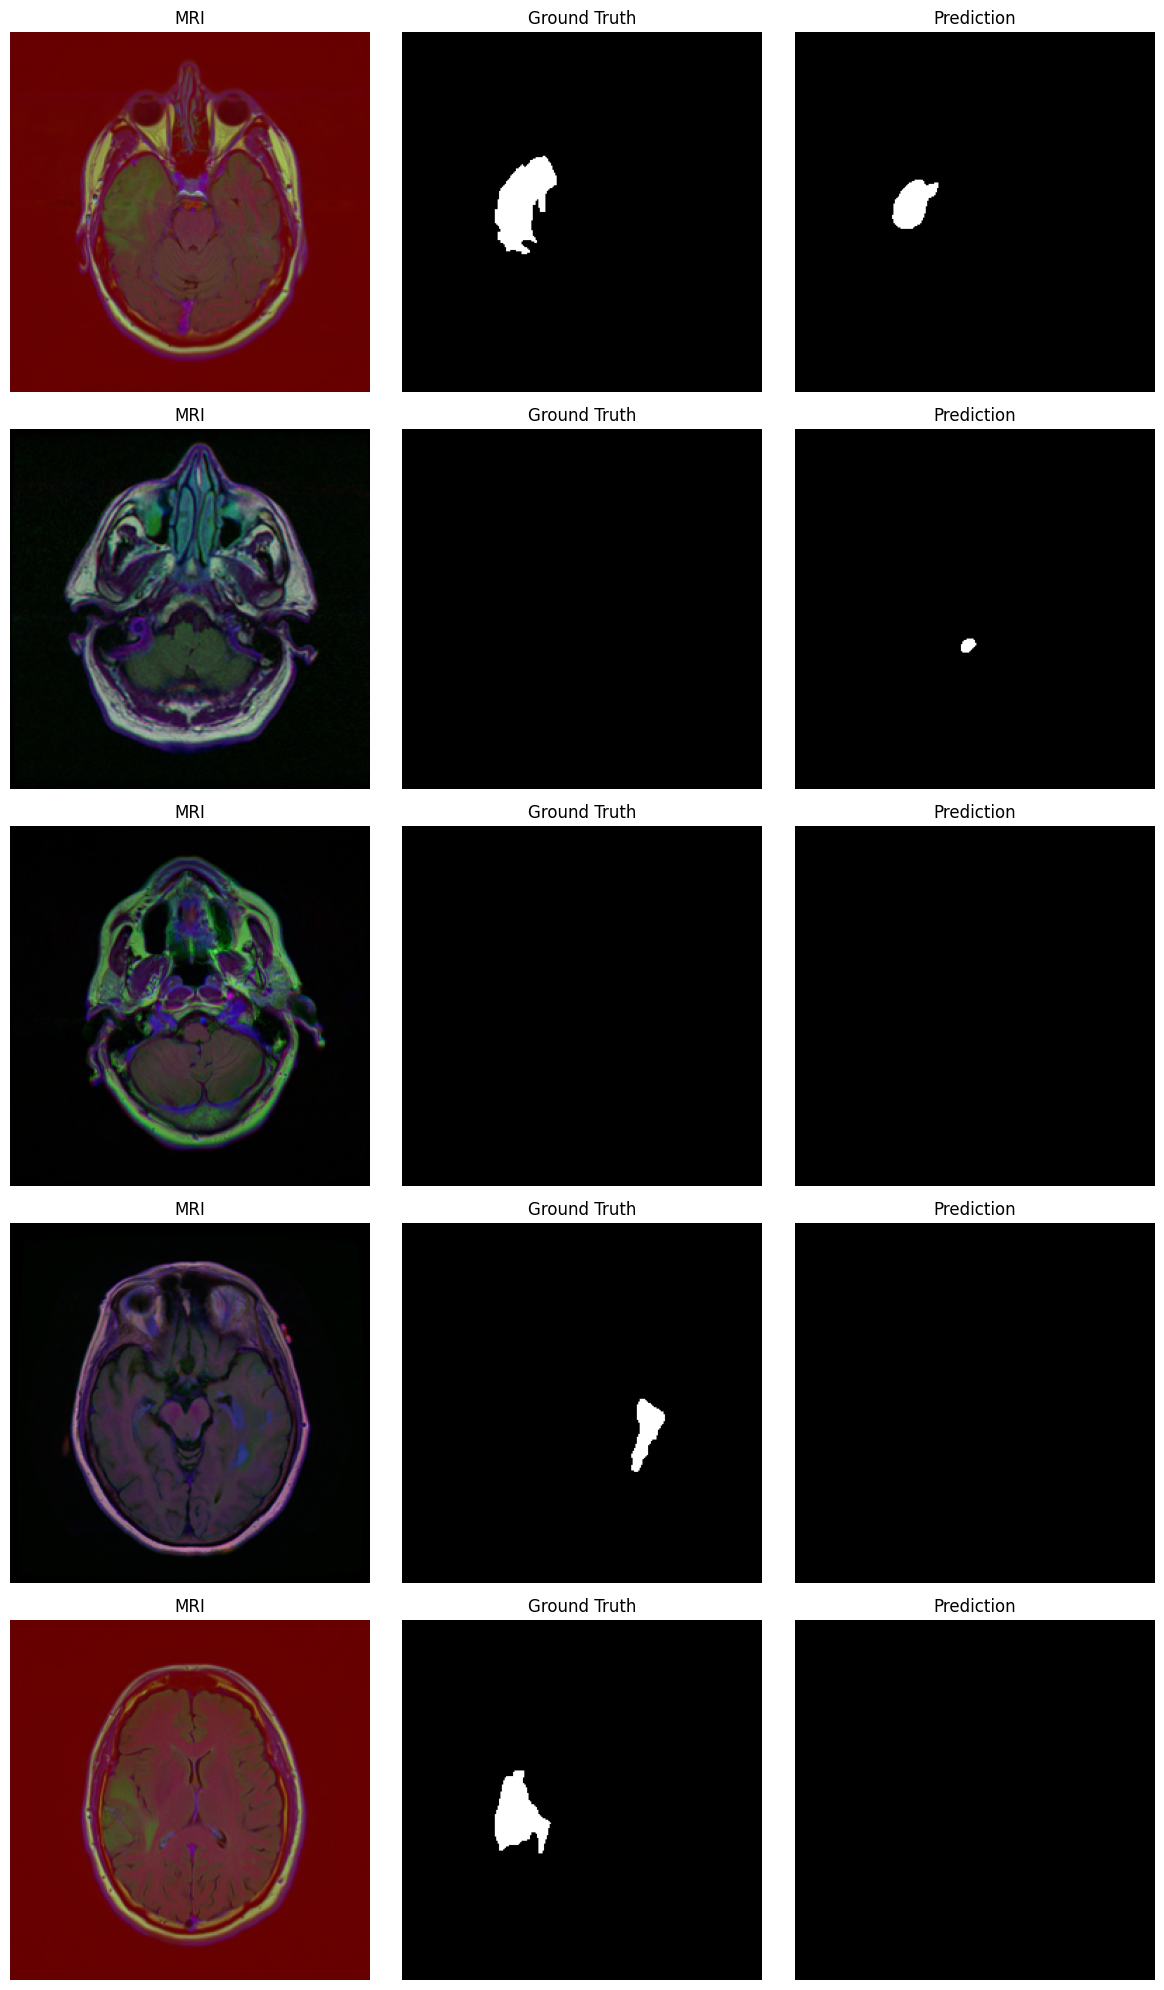

In [43]:
# Load best saved model
model.load_state_dict(torch.load("best_unet_model.pth"))
model.eval()

# Select random samples from validation set
num_samples = 5
indices = np.random.choice(len(val_dataset), num_samples)

plt.figure(figsize=(12, num_samples * 4))

for i, idx in enumerate(indices):

    image, mask = val_dataset[idx]

    with torch.no_grad():
        pred = model(
            image.unsqueeze(0).to(device)
        )

        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()

    image = image.permute(1, 2, 0).numpy()
    mask = mask.squeeze().numpy()
    pred = pred.squeeze().cpu().numpy()

    # MRI image
    plt.subplot(num_samples, 3, i * 3 + 1)
    plt.imshow(image)
    plt.title("MRI")
    plt.axis("off")

    # Ground truth
    plt.subplot(num_samples, 3, i * 3 + 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(num_samples, 3, i * 3 + 3)
    plt.imshow(pred, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

Best model saved.
Epoch [1/30] | Train Loss: 0.6252 | Val Loss: 0.5624 | Dice: 0.4701 | Best Dice: 0.4701
Best model saved.
Epoch [2/30] | Train Loss: 0.5154 | Val Loss: 0.4697 | Dice: 0.4987 | Best Dice: 0.4987
Epoch [3/30] | Train Loss: 0.4275 | Val Loss: 0.4055 | Dice: 0.4498 | Best Dice: 0.4987
Best model saved.
Epoch [4/30] | Train Loss: 0.3315 | Val Loss: 0.3160 | Dice: 0.5516 | Best Dice: 0.5516
Epoch [5/30] | Train Loss: 0.2626 | Val Loss: 0.2873 | Dice: 0.5430 | Best Dice: 0.5516
Best model saved.
Epoch [6/30] | Train Loss: 0.2238 | Val Loss: 0.2433 | Dice: 0.5931 | Best Dice: 0.5931
Best model saved.
Epoch [7/30] | Train Loss: 0.2027 | Val Loss: 0.2038 | Dice: 0.6892 | Best Dice: 0.6892
Best model saved.
Epoch [8/30] | Train Loss: 0.1905 | Val Loss: 0.2009 | Dice: 0.6902 | Best Dice: 0.6902
Epoch [9/30] | Train Loss: 0.1785 | Val Loss: 0.1944 | Dice: 0.6755 | Best Dice: 0.6902
Best model saved.
Epoch [10/30] | Train Loss: 0.1671 | Val Loss: 0.1696 | Dice: 0.7298 | Best Dice: 

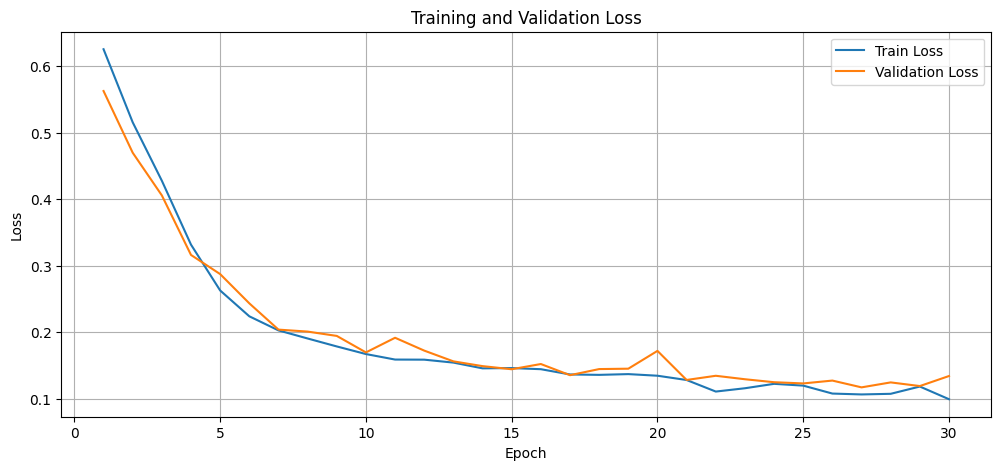

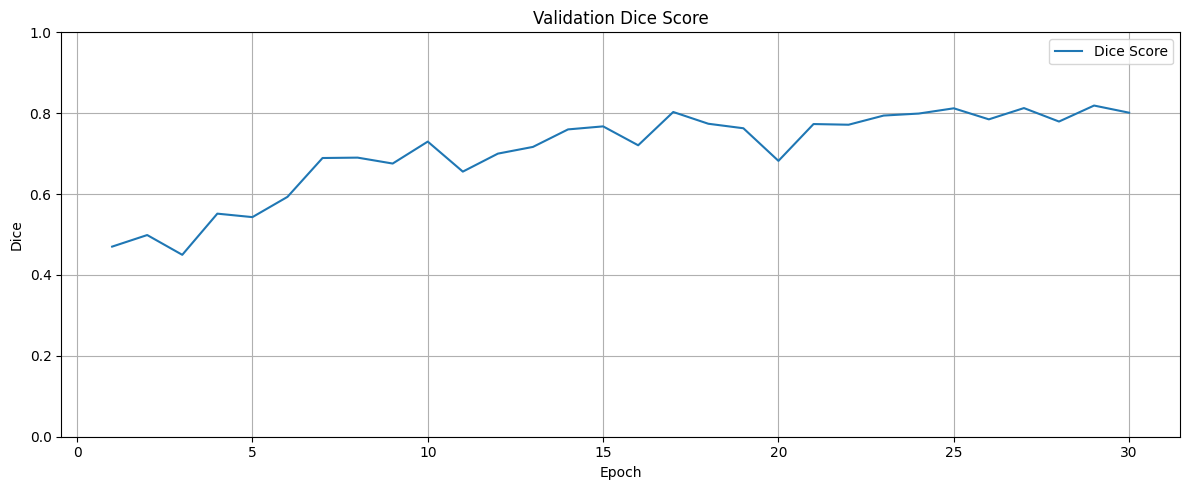

Training Finished
Best Dice Score: 0.8190


In [ ]:
#Training
def train(model, dataloader, optimizer):
    model.train()
    total_loss = 0
    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = (
            0.5 * bce_loss(outputs, masks)
            +
            0.5 * dice_loss(outputs, masks)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

# Validation
def validate(model, dataloader):
    model.eval()
    total_loss = 0
    total_dice = 0
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            loss = (
                0.5 * bce_loss(outputs, masks)
                +
                0.5 * dice_loss(outputs, masks)
            )
            total_loss += loss.item()
            outputs = torch.sigmoid(outputs)
            outputs = (outputs > 0.5).float()
            intersection = (outputs * masks).sum()
            dice = (
                2 * intersection + 1e-8
            ) / (
                outputs.sum() + masks.sum() + 1e-8
            )
            total_dice += dice.item()

    avg_loss = total_loss / len(dataloader)
    avg_dice = total_dice / len(dataloader)

    return avg_loss, avg_dice

train_losses = []
val_losses = []
dice_scores = []
num_epochs = 30
best_dice = 0.0
patience = 8
patience_counter = 0

for epoch in range(num_epochs):

    train_loss = train(
        model,
        train_loader,
        optimizer
    )

    val_loss, dice_score = validate(
        model,
        val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    dice_scores.append(dice_score)

    # Early Stopping + Save Best Model
    if dice_score > best_dice:
        best_dice = dice_score
        patience_counter = 0
        torch.save(
            model.state_dict(),
            "best_model_improved_baseline_unet.pth"
        )
        print("Best model saved.")
    else:
        patience_counter += 1

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {dice_score:.4f} | "
        f"Best Dice: {best_dice:.4f}"
    ) 
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

    

# Plot training and validation losses
plt.figure(figsize=(12,5))
plt.plot(
    range(1, len(train_losses)+1),
    train_losses,
    label="Train Loss"
)
plt.plot(
    range(1, len(val_losses)+1),
    val_losses,
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

# Plot Dice Score
plt.figure(figsize=(12,5))
plt.plot(
    range(1, len(dice_scores)+1),
    dice_scores,
    label="Dice Score"
)

plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Validation Dice Score")
plt.ylim(0, 1)
plt.legend() 
plt.grid()
plt.tight_layout()
plt.show()

print("Training Finished")
print(f"Best Dice Score: {best_dice:.4f}")

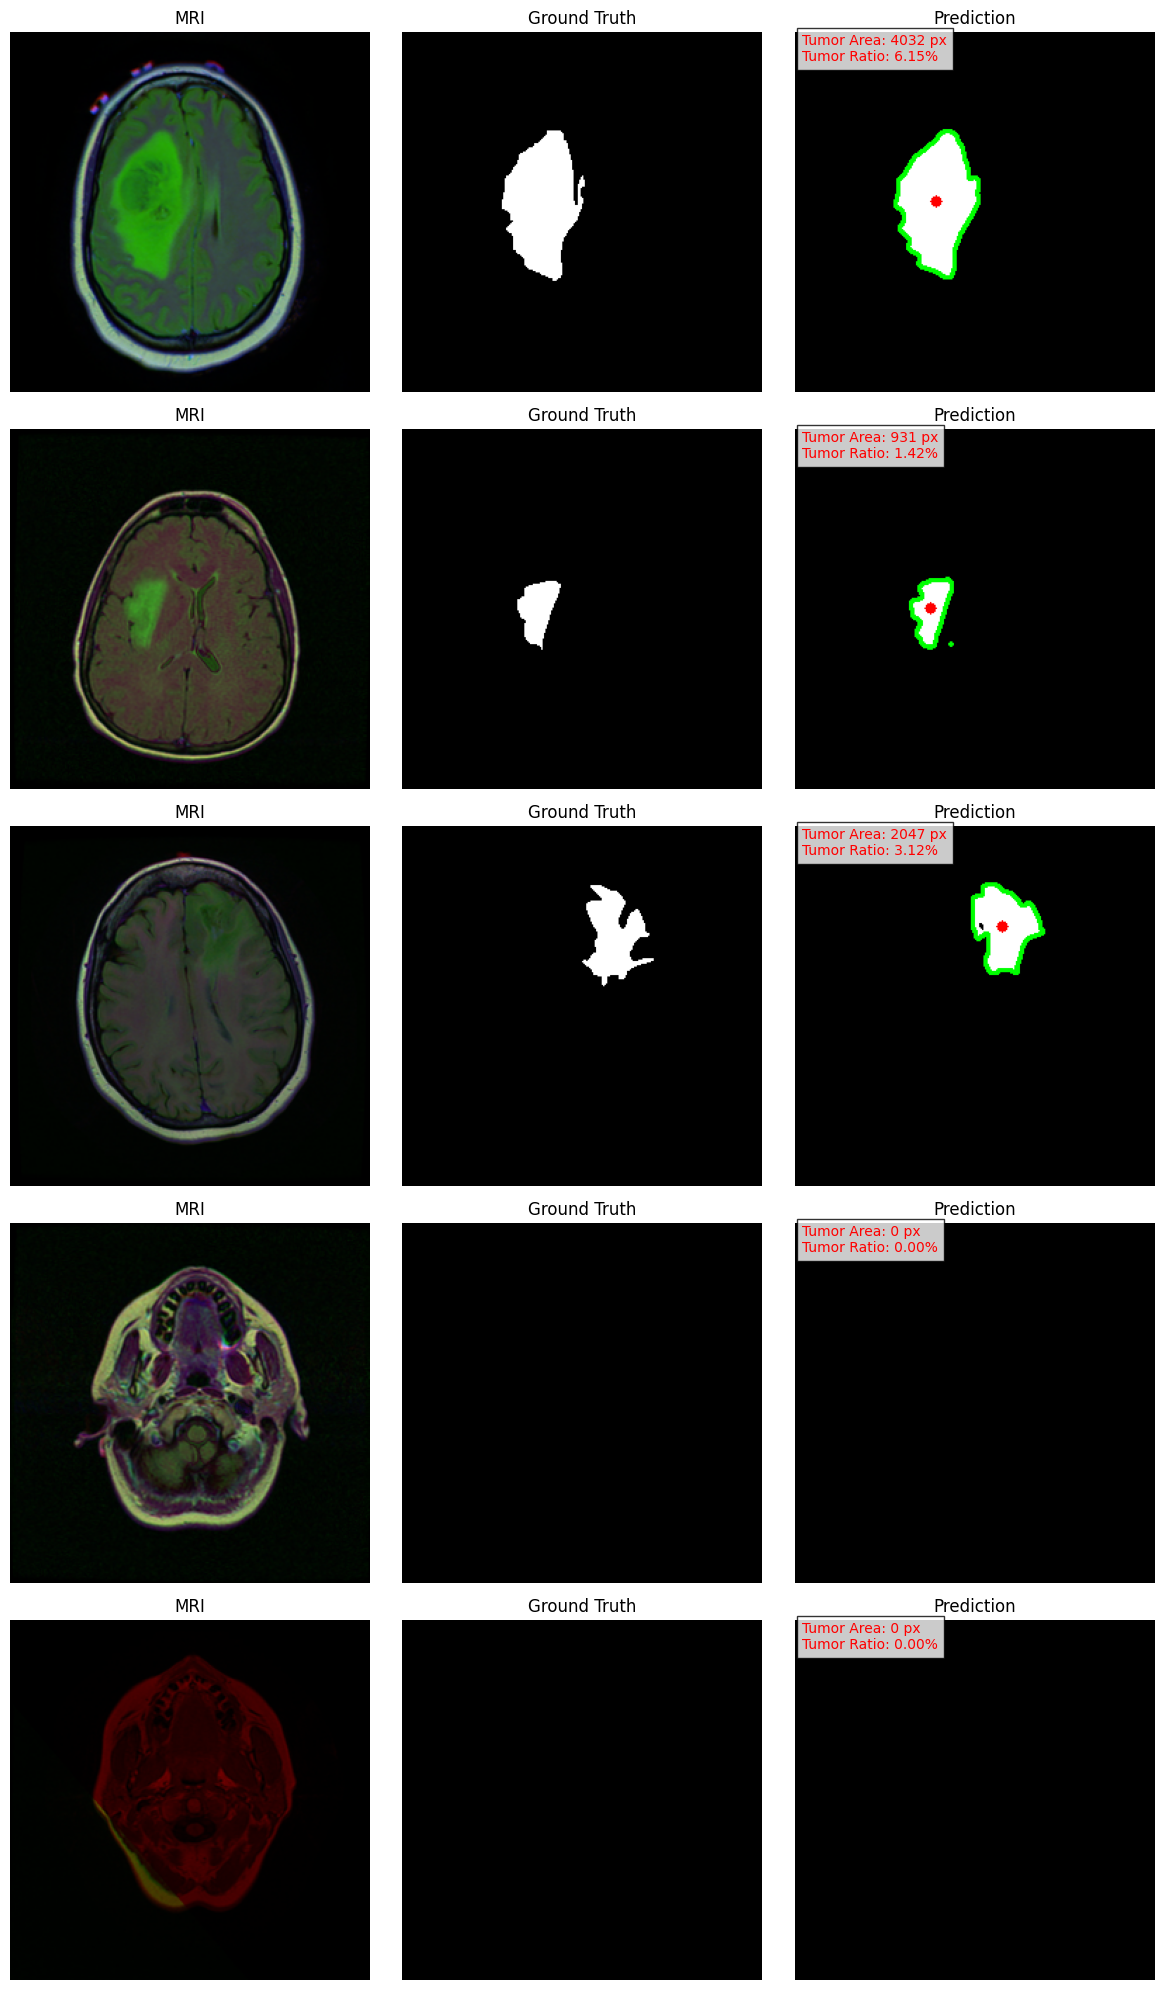

In [ ]:
# Load best saved model
model.load_state_dict(torch.load("best_model_improved_baseline_unet.pth", map_location=device))
model.eval()

# Select random samples from validation set
num_samples = 5
indices = np.random.choice(len(val_dataset), num_samples)

plt.figure(figsize=(12, num_samples * 4))

for i, idx in enumerate(indices):

    image, mask = val_dataset[idx]

    with torch.no_grad():
        pred = model(
            image.unsqueeze(0).to(device)
        )

        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()

    image = image.permute(1, 2, 0).numpy()
    mask = mask.squeeze().numpy()
    pred = pred.squeeze().cpu().numpy()

    # Tumor area calculation
    tumor_pixels = np.sum(pred)
    total_pixels = pred.shape[0] * pred.shape[1]
    tumor_percentage = (tumor_pixels / total_pixels) * 100
     
    # Find contours
    pred_uint8 = (pred * 255).astype("uint8")

    contours, _ = cv2.findContours(
        pred_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    # Convert prediction to RGB for visualization
    pred_rgb = cv2.cvtColor(pred_uint8, cv2.COLOR_GRAY2RGB)

    # Draw contours
    cv2.drawContours(
        pred_rgb,
        contours,
        -1,
        (0, 255, 0),
        2
    )
    # Draw tumor centroid
    if len(contours) > 0:

        largest_contour = max(contours, key=cv2.contourArea)

        M = cv2.moments(largest_contour)

        if M["m00"] != 0:

            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])

            cv2.circle(
                pred_rgb,
                (cx, cy),
                4,
                (255, 0, 0),
                -1
            )

    # MRI image
    plt.subplot(num_samples, 3, i * 3 + 1)
    plt.imshow(image)
    plt.title("MRI")
    plt.axis("off")

    # Ground truth
    plt.subplot(num_samples, 3, i * 3 + 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(num_samples, 3, i * 3 + 3)
    plt.imshow(pred_rgb)
    plt.text(
        5,
        20,
        f"Tumor Area: {tumor_pixels:.0f} px\n"
        f"Tumor Ratio: {tumor_percentage:.2f}%",
        color="red",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8)
    )
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()